In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.shape

(1460, 81)

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [7]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
train.drop(columns = ['Id'], inplace = True)

In [9]:
train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [10]:
train.drop_duplicates(inplace = True)

In [11]:
train.shape

(1460, 80)

In [12]:
train.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [13]:
import matplotlib.pyplot as plt

In [14]:
sns.set_style('darkgrid')

<Axes: ylabel='MSSubClass'>

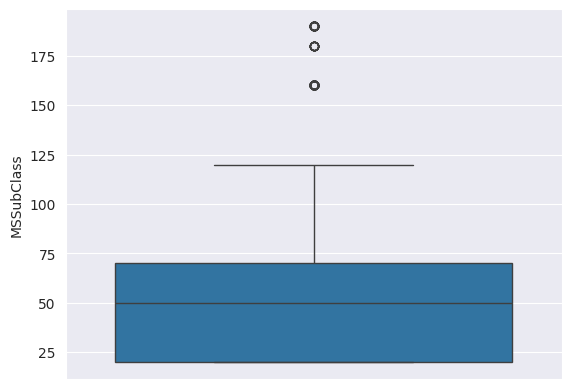

In [15]:
sns.boxplot(train, y = 'MSSubClass')

In [16]:
num_cols = train.select_dtypes('int').columns.tolist()
len(num_cols)

34

In [17]:
corr = train.corr(numeric_only=True)

corr['SalePrice'].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

In [18]:
import matplotlib.pyplot as plt

sns.set_style('darkgrid')

<Axes: ylabel='OverallQual'>

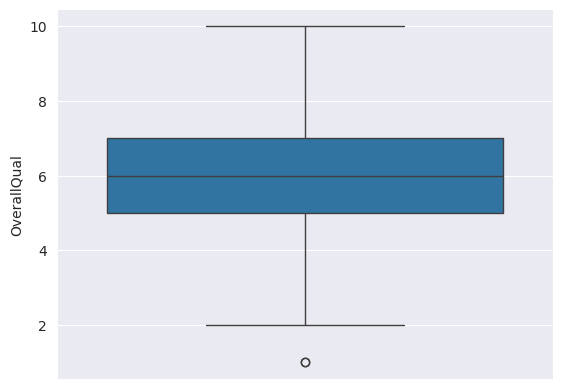

In [19]:
sns.boxplot(train, y = 'OverallQual')

<Axes: ylabel='GrLivArea'>

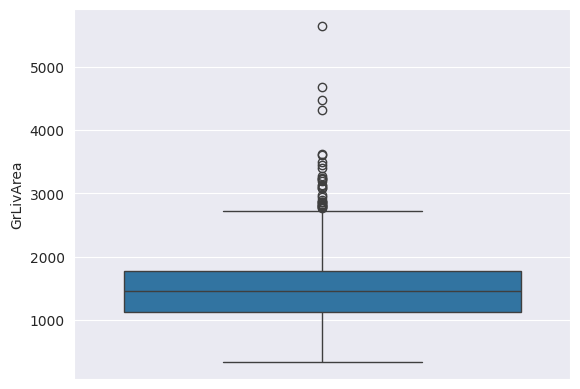

In [20]:
sns.boxplot(train, y = 'GrLivArea')

<Axes: ylabel='GarageCars'>

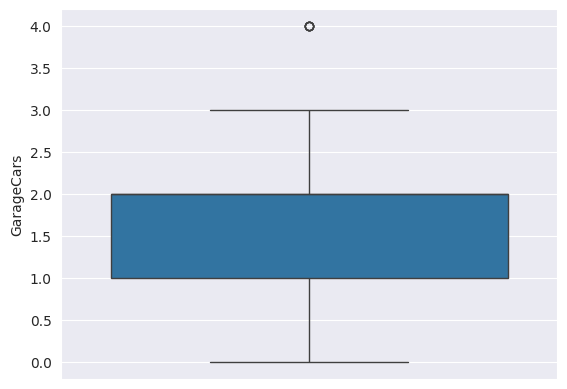

In [21]:
sns.boxplot(train, y = 'GarageCars')

<Axes: ylabel='GarageArea'>

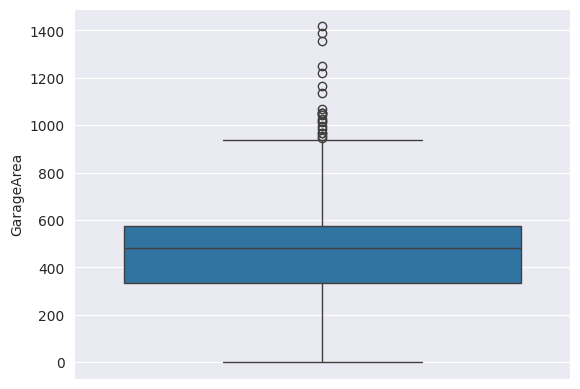

In [22]:
sns.boxplot(train, y = 'GarageArea')

<Axes: ylabel='TotalBsmtSF'>

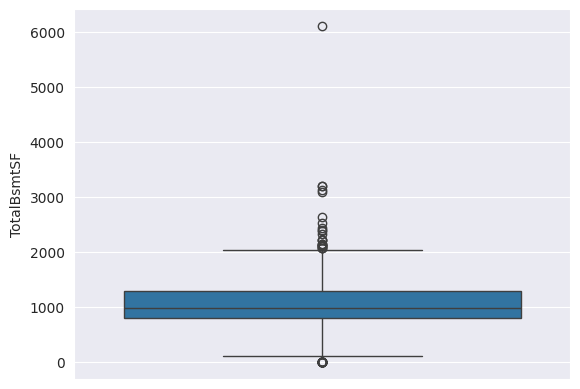

In [23]:
sns.boxplot(train, y = 'TotalBsmtSF')

<Axes: ylabel='1stFlrSF'>

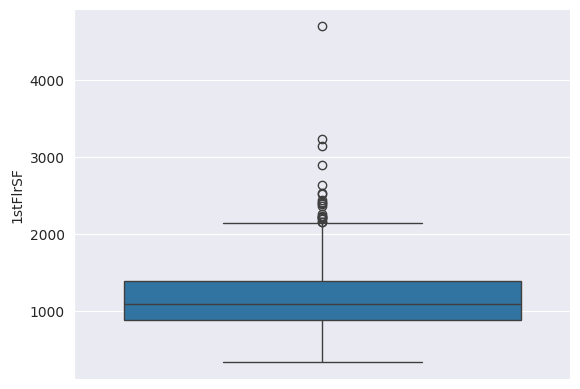

In [24]:
sns.boxplot(train, y = '1stFlrSF')

<Axes: ylabel='FullBath'>

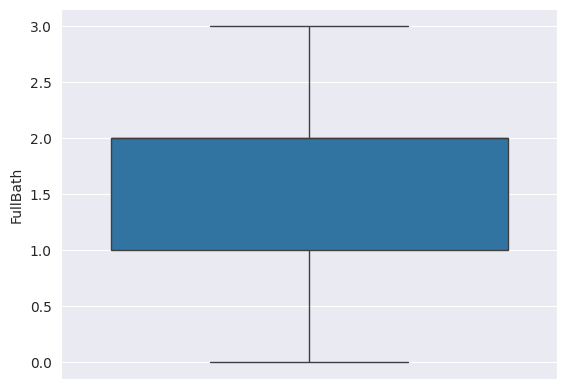

In [25]:
sns.boxplot(train, y = 'FullBath')

<Axes: ylabel='TotRmsAbvGrd'>

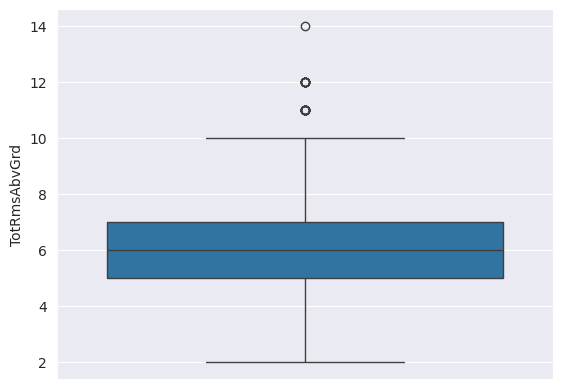

In [26]:
sns.boxplot(train, y = 'TotRmsAbvGrd')

<Axes: ylabel='YearBuilt'>

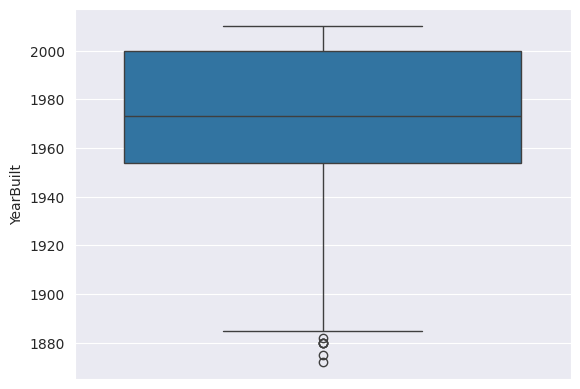

In [27]:
sns.boxplot(train, y = 'YearBuilt')

<Axes: ylabel='YearRemodAdd'>

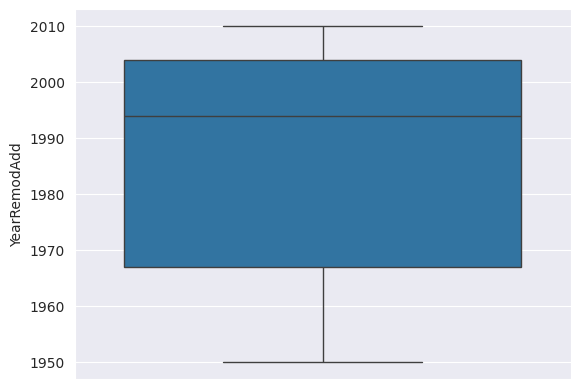

In [28]:
sns.boxplot(train, y =  'YearRemodAdd')

<Axes: ylabel='GarageYrBlt'>

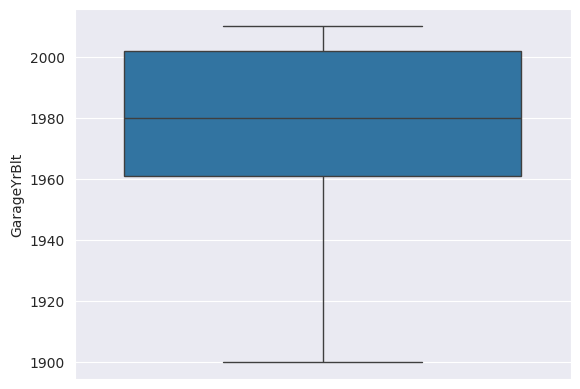

In [29]:
sns.boxplot(train, y = 'GarageYrBlt')

<Axes: ylabel='MasVnrArea'>

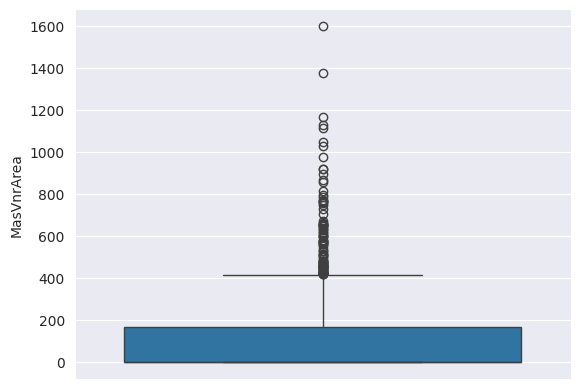

In [30]:
sns.boxplot(train, y = 'MasVnrArea')

<Axes: ylabel='Fireplaces'>

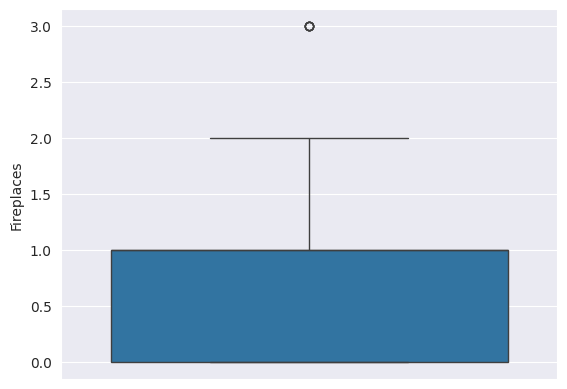

In [31]:
sns.boxplot(train, y = 'Fireplaces')

<Axes: ylabel='BsmtFinSF1'>

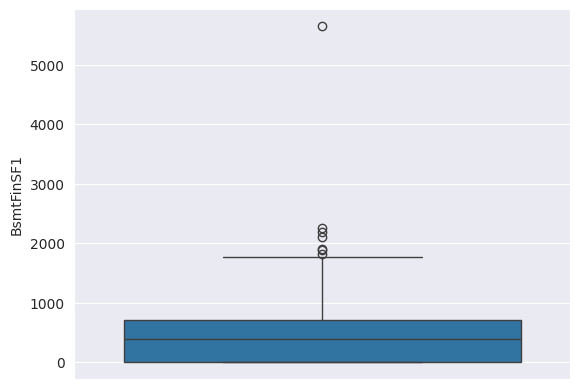

In [32]:
sns.boxplot(train, y = 'BsmtFinSF1')

<Axes: ylabel='SalePrice'>

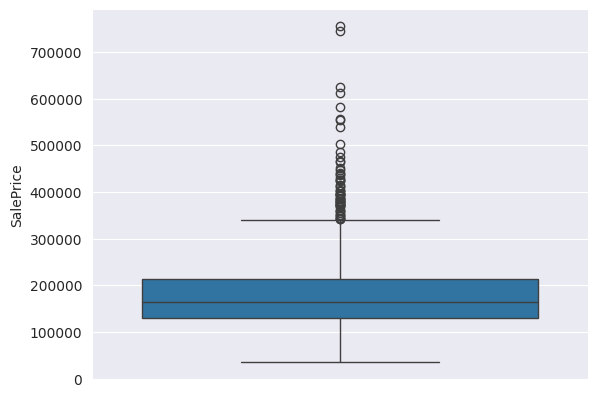

In [33]:
sns.boxplot(train, y = 'SalePrice')

In [34]:
train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [35]:
import numpy as np

In [36]:
Q1 = np.percentile(train['GrLivArea'], 25, method = 'midpoint')
Q3 = np.percentile(train['GrLivArea'], 75, method = 'midpoint')

In [37]:
IQR = Q3- Q1

In [38]:
lowerbound = Q1 - 1.5 * IQR
upperbound = Q3 + 1.5 * IQR

In [39]:
train = train[(train.GrLivArea < upperbound) & (train.GrLivArea > lowerbound)]

In [40]:
train.shape

(1429, 80)

In [41]:
train_original = train.copy()

In [42]:
missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

PoolQC          1426
MiscFeature     1377
Alley           1340
Fence           1155
MasVnrType       859
FireplaceQu      689
LotFrontage      254
GarageQual        79
GarageType        79
GarageFinish      79
GarageCond        79
GarageYrBlt       79
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
dtype: int64

In [43]:
train.drop(columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence'], 
          axis = 1, inplace = True)

In [44]:
train['FireplaceQu'] = train['FireplaceQu'].fillna('None')

In [45]:
train['MasVnrType'] = train['MasVnrType'].fillna('None')
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

In [46]:
train['LotFrontage'] = train['LotFrontage'].fillna(
    train['LotFrontage'].median()
)

In [47]:
train['GarageQual'] = train['GarageQual'].fillna('None')
train['GarageType'] = train['GarageType'].fillna('None')
train['GarageFinish'] = train['GarageFinish'].fillna('None')
train['GarageCond'] = train['GarageCond'].fillna('None')
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

In [48]:
train['BsmtExposure'] = train['BsmtExposure'].fillna('None')
train['BsmtFinType2'] = train['BsmtFinType2'].fillna('None')
train['BsmtQual'] = train['BsmtQual'].fillna('None')
train['BsmtFinType1'] = train['BsmtFinType1'].fillna('None')
train['BsmtCond'] = train['BsmtCond'].fillna('None')

In [49]:
train['Electrical'] = train['Electrical'].fillna(
    train['Electrical'].mode()[0])

In [50]:
train.isna().sum().sort_values(ascending = False).head(20)

MSSubClass      0
MSZoning        0
LotFrontage     0
LotArea         0
Street          0
LotShape        0
LandContour     0
Utilities       0
LotConfig       0
LandSlope       0
Neighborhood    0
Condition1      0
Condition2      0
BldgType        0
HouseStyle      0
OverallQual     0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
RoofStyle       0
dtype: int64

In [51]:
train['SalePrice'].skew()

np.float64(1.3507178707417062)

In [52]:
train['SalePrice'] = np.log1p(train['SalePrice'])

In [53]:
train['SalePrice'].skew()

np.float64(-0.02750679742392261)

In [54]:
cat_col = train.select_dtypes('object').columns.tolist

In [55]:
cat_col

<bound method IndexOpsMixin.tolist of Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')>

In [56]:
X = train.drop(columns = 'SalePrice', axis = 1)
y = train['SalePrice']

In [57]:
X.shape, y.shape

((1429, 75), (1429,))

In [58]:
X = pd.get_dummies(X, drop_first=True)

In [59]:
X.shape

(1429, 244)

In [60]:
X = train.drop(columns = 'SalePrice', axis = 1)
y = train['SalePrice']

In [61]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(1429, 244)


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   test_size = 0.2,
                                                   random_state = 42)

In [63]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1143, 244), (286, 244), (1143,), (286,))

In [64]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [65]:
y_pred = model.predict(X_test)

In [66]:
y_pred[:5]

array([11.55798343, 11.70975973, 12.00734701, 11.66675659, 12.59007856])

In [67]:
y_test[:5]

125     11.344519
1214    11.809327
469     12.138869
358     11.775297
1027    12.588194
Name: SalePrice, dtype: float64

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [69]:
mean_absolute_error(y_test, y_pred)

0.08554070766513656

In [70]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(0.12732033410885604)

In [71]:
r2_score(y_test, y_pred)

0.8853620238008246

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

Ridge()

In [74]:
ridge_pred = ridge.predict(X_test_scaled)

In [75]:
mean_absolute_error(y_test, ridge_pred)

0.08543765228029356

In [76]:
np.sqrt(mean_squared_error(y_test, ridge_pred))

np.float64(0.12725903748278408)

In [77]:
r2_score(y_test, ridge_pred)

0.885472378988039

In [78]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha = 0.001)

In [79]:
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.001)

In [80]:
lasso_pred = lasso.predict(X_test_scaled)

In [81]:
mean_absolute_error(y_test, lasso_pred)

0.08101033042935894

In [82]:
np.sqrt(mean_squared_error(y_test, lasso_pred))

np.float64(0.1218343849753483)

In [83]:
r2_score(y_test, lasso_pred)

0.8950281812511696

In [84]:
lasso.alpha

0.001

In [85]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

In [86]:
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [87]:
mean_absolute_error(y_test, rf_pred)

0.09069839592918887

In [88]:
np.sqrt(mean_squared_error(y_test, rf_pred))

np.float64(0.13658090753405375)

In [89]:
r2_score(y_test, rf_pred)

0.8680792962229616

In [90]:
coefficients = pd.DataFrame({'Feature' : X_train.columns,
                            'Coefficient' : lasso.coef_})

In [91]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest'],
    'R2': [0.8854, 0.8855, 0.8950, 0.8681]
})

results

,Model,R2
0,Linear Regression,0.8854
1,Ridge,0.8855
2,Lasso,0.8950
3,Random Forest,0.8681


In [92]:
coefficients['AbsCoeff'] = abs(coefficients['Coefficient'])

In [93]:
coefficients.sort_values(by = 'AbsCoeff', ascending = False).head(20)

,Feature,Coefficient,AbsCoeff
15,GrLivArea,0.119218,0.119218
3,OverallQual,0.066538,0.066538
5,YearBuilt,0.052531,0.052531
38,MSZoning_RL,0.043684,0.043684
11,TotalBsmtSF,0.041220,0.041220
4,OverallCond,0.040656,0.040656
8,BsmtFinSF1,0.029019,0.029019
2,LotArea,0.025607,0.025607
36,MSZoning_FV,0.025538,0.025538
242,SaleCondition_Normal,0.025361,0.025361


In [94]:
top20 = coefficients.sort_values(by = 'AbsCoeff', 
                                 ascending = False).head(20)

In [95]:
import matplotlib.pyplot as plt

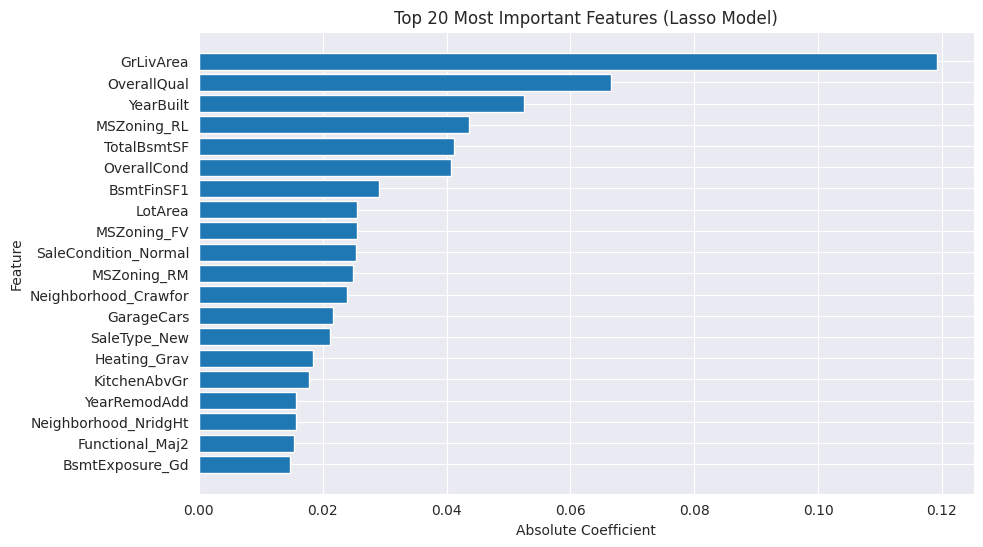

In [96]:
plt.figure(figsize = (10, 6))
plt.barh(top20['Feature'], top20['AbsCoeff'])
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.title('Top 20 Most Important Features (Lasso Model)')
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Analysis

Feature importance was analyzed using the coefficients of the Lasso Regression model.

The most influential features were:

- GrLivArea (Ground Living Area)
- OverallQual (Overall Quality)
- YearBuilt
- TotalBsmtSF (Total Basement Area)
- LotArea

The results indicate that larger homes, better construction quality, newer houses, and larger basements contribute significantly to higher house prices.

### Feature Importance Observations

- GrLivArea is the most influential feature in predicting house prices.
- OverallQual and YearBuilt also contribute significantly.
- Basement area and zoning-related variables show moderate influence.
- House size, quality, and construction year are the primary drivers of sale price.

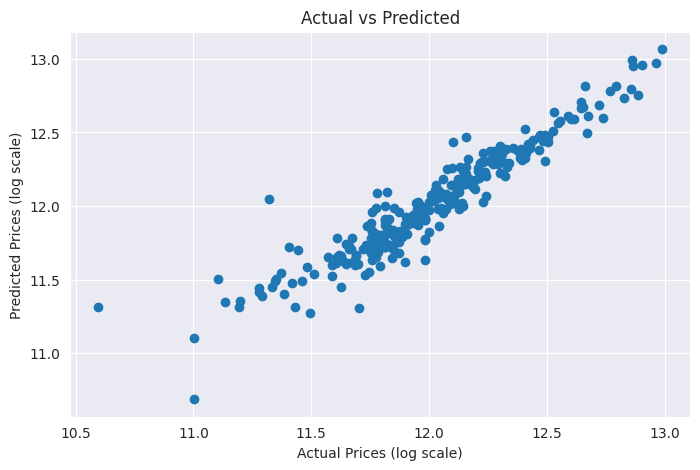

In [97]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, lasso_pred)
plt.xlabel("Actual Prices (log scale)")
plt.ylabel("Predicted Prices (log scale)")
plt.title("Actual vs Predicted")
plt.show()

### Actual vs Predicted Analysis

- Most predictions lie close to the ideal diagonal line.
- The model captures the overall trend of house prices effectively.
- Small deviations indicate prediction errors for some properties.
- The plot demonstrates strong predictive performance.

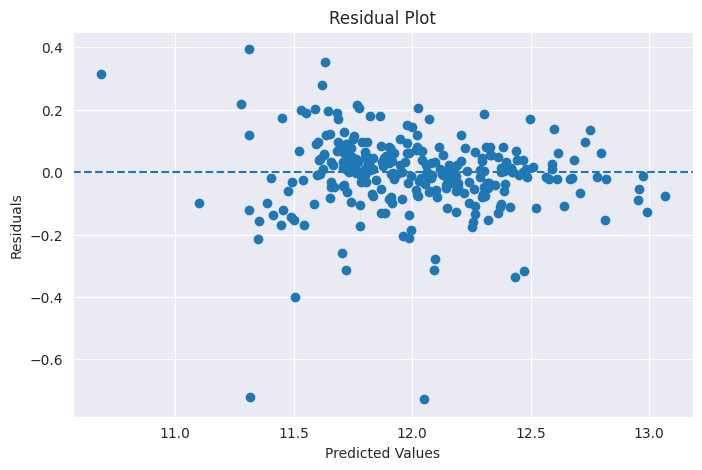

In [98]:
import matplotlib.pyplot as plt

residuals = y_test - lasso_pred

plt.figure(figsize=(8,5))
plt.scatter(lasso_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Residual Analysis

- Residuals are centered around zero.
- No strong systematic pattern is visible.
- The variance appears reasonably constant across predictions.
- This suggests that the model assumptions are largely satisfied.

In [99]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest'],
    'R2': [0.88536, 0.88547, 0.89503, 0.86808],
    'MAE': [0.08554, 0.08544, 0.08101, 0.09070],
    'RMSE': [0.12732, 0.12726, 0.12183, 0.13658]
})

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.88536,0.08554,0.12732
1,Ridge,0.88547,0.08544,0.12726
2,Lasso,0.89503,0.08101,0.12183
3,Random Forest,0.86808,0.09070,0.13658


### Model Comparison Observations

- Lasso Regression achieved the highest R² score (0.895).
- Lasso also produced the lowest MAE and RMSE.
- Ridge and Linear Regression performed similarly.
- Random Forest achieved lower performance than the linear models.
- Therefore, Lasso Regression was selected as the final model.

# Conclusion

After data cleaning, missing value handling, outlier treatment, feature engineering, and model evaluation, Lasso Regression achieved the best performance with:

- R² = 0.895
- MAE = 0.081
- RMSE = 0.122

The most important factors affecting house prices were:
- GrLivArea
- OverallQual
- YearBuilt
- TotalBsmtSF
- OverallCond

This model can explain approximately 89.5% of the variation in house prices and was selected as the final prediction model.